In [1]:
from ModelClass import RegressionModel
from DatasetClass import Dataset, DatasetMass
from src.helpers import pick_only_target, extract_data, pick_only_mmc
import matplotlib.pyplot as plt
import numpy as np
import itertools
from src.helpers import make_filter_slice
import tensorflow as tf
#import optuna 
#from optuna_dashboard import run_server
import threading



2025-07-01 21:28:10.680413: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-01 21:28:10.692456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751398090.705086 1610443 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751398090.708910 1610443 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-01 21:28:10.724134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Available GPUs: []


2025-07-01 21:28:14.411017: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
Model_Name = "PatrikNet_phi_flattened_17s_20_200.keras"

In [12]:
plt.rcParams.update({
    # from rootpy
    'lines.linewidth': 1,

    # font
    'font.family': 'sans-serif',
    'font.sans-serif': ['helvetica', 'Helvetica', 'Nimbus Sans L', 'Mukti Narrow', 'FreeSans'],
    'font.size': 18,
    'mathtext.fontset': 'stixsans',
    'mathtext.default': 'rm',

    # figure layout
    'figure.figsize': [8.75, 5.92],
    'figure.facecolor': 'white',
    'figure.subplot.bottom': 0.16,
    'figure.subplot.top': 0.93,
    'figure.subplot.left': 0.16,
    'figure.subplot.right': 0.95,

    # axes
    'axes.labelsize': 30,
    'axes.labelpad': 10,

    # ticks
    'xtick.top': True,
    'xtick.labelsize': 19,
    'xtick.major.size': 10,
    'xtick.minor.size': 5,
    'xtick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.right': True,
    'ytick.labelsize': 19,
    'ytick.major.size': 14,
    'ytick.minor.size': 7,
    'ytick.direction': 'in',
    'ytick.minor.visible': True,
    
    # lines
    'lines.markersize': 8,

    # legend
    'legend.numpoints': 1,
    'legend.fontsize': 18,
    'legend.labelspacing': 0.3,
    'legend.frameon': False,
})

In [4]:
dataset_h125 = DatasetMass()
dataset_h125.load_data(file_name = "data_h125")

dataset_Ztt = DatasetMass()
dataset_Ztt.load_data(file_name = "data_mmc")

In [5]:
#TRUE Golden Values
y_true_H125 = np.array(extract_data(dataset_h125.val_dataset.map(pick_only_target)))
y_true_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_target)))

y_true_H125 = np.concatenate([y_true_H125, np.array(extract_data(dataset_h125.dev_dataset.map(pick_only_target)))])
y_true_Ztt = np.concatenate([y_true_Ztt, np.array(extract_data(dataset_Ztt.dev_dataset.map(pick_only_target)))])

2025-07-01 21:28:58.730673: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-01 21:29:36.825680: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-01 21:30:46.085240: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
#MMC Predictions
y_mmc_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_mmc)))
y_mmc_H125 = np.array(extract_data(dataset_h125.val_dataset.map(pick_only_mmc)))

y_mmc_Ztt = np.concatenate([y_mmc_Ztt, np.array(extract_data(dataset_Ztt.dev_dataset.map(pick_only_mmc)))])
y_mmc_H125 = np.concatenate([y_mmc_H125, np.array(extract_data(dataset_h125.dev_dataset.map(pick_only_mmc)))])


2025-07-01 21:33:06.509155: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# NN Predictions
print("Predicting Ztt masses...")
model_Ztt = RegressionModel(dataset=dataset_Ztt)
model_Ztt.load(model_name=Model_Name)
y_pred_Ztt = model_Ztt.model.predict(dataset_Ztt.val_dataset.batch(10000)).squeeze()
y_pred_Ztt = np.concatenate([y_pred_Ztt, model_Ztt.model.predict(dataset_Ztt.dev_dataset.batch(10000)).squeeze()])

print("Predicting H125 masses...")
model_H125 = RegressionModel(dataset=dataset_h125)
model_H125.load(model_name=Model_Name)
y_pred_H125 = model_H125.model.predict(dataset_h125.val_dataset.batch(10000)).squeeze()
y_pred_H125 = np.concatenate([y_pred_H125, model_H125.model.predict(dataset_h125.dev_dataset.batch(10000)).squeeze()])

Predicting Ztt masses...
Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_phi_flattened_17s_20_200.keras


I0000 00:00:1751398387.333111 1616053 service.cc:148] XLA service 0x7fe754005db0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751398387.337866 1616053 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-07-01 21:33:07.565833: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 3/98 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step

I0000 00:00:1751398388.096726 1616053 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step
Predicting H125 masses...
Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_phi_flattened_17s_20_200.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

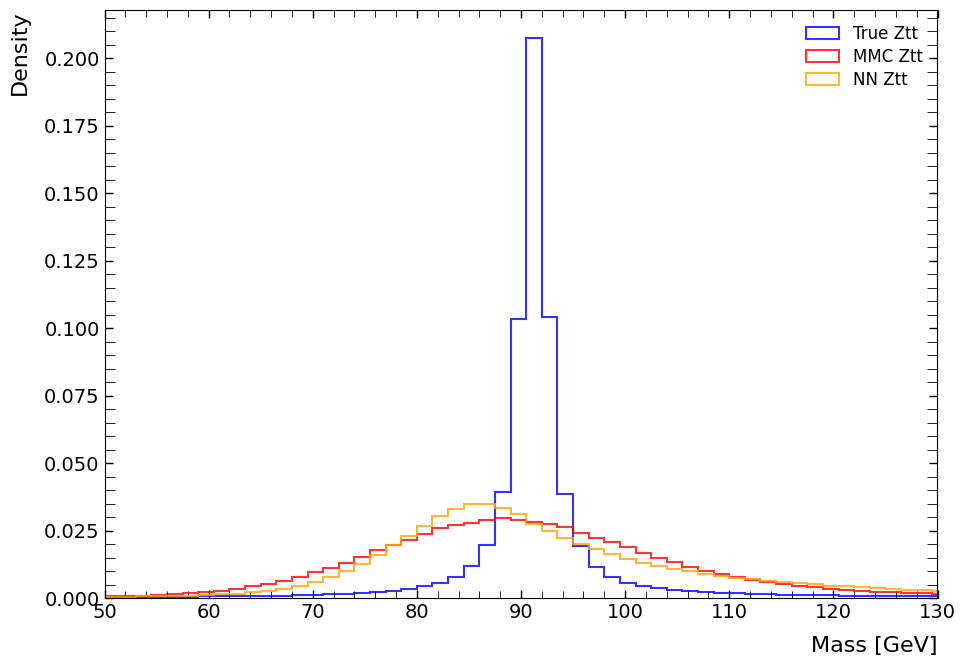

In [28]:
# MMC vs NN vs True Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_true_Ztt, bins=120, range=(20, 200), histtype='step',
         label='True Ztt', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',
         label='MMC Ztt', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Orange', alpha=0.8, linewidth=1.5)


plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(50, 130)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.savefig('out/Ztt_True_NN_MM_phi.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

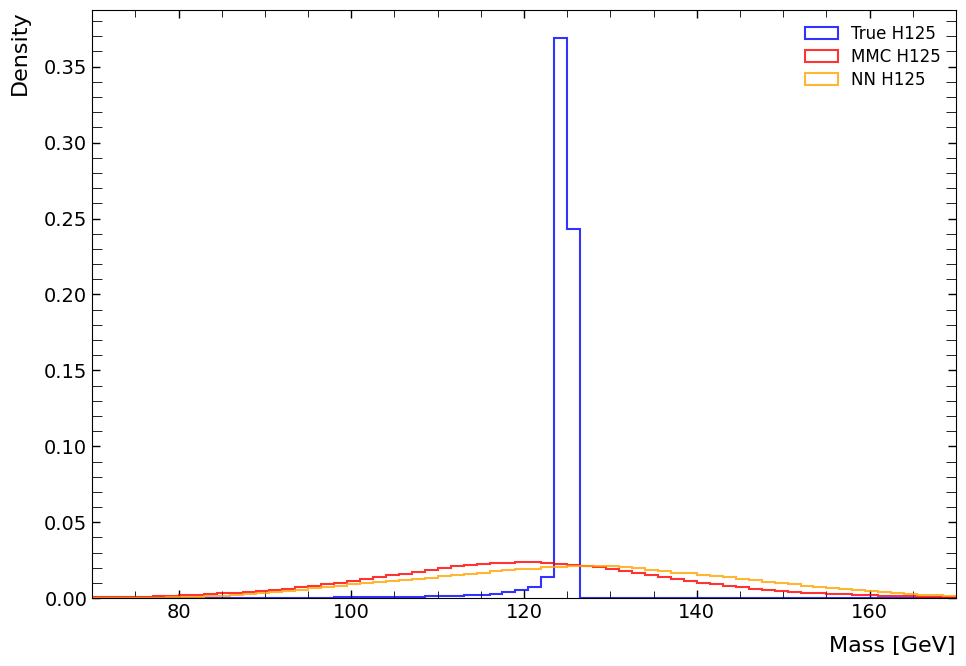

In [17]:
# MMC vs NN vs True
plt.figure(figsize=(10, 7))
plt.hist(y_true_H125, bins=120, range=(20, 200), histtype='step',
         label='True H125', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_H125, bins=120, range=(20, 200), histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=120, range=(20, 200), histtype='step',
         label='NN H125', density=True, color='Orange', alpha=0.8, linewidth=1.5)       
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(70, 170)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.savefig('out/H125_True_NN_MMC_phi.png', dpi=300)
plt.tight_layout()
plt.show()      

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

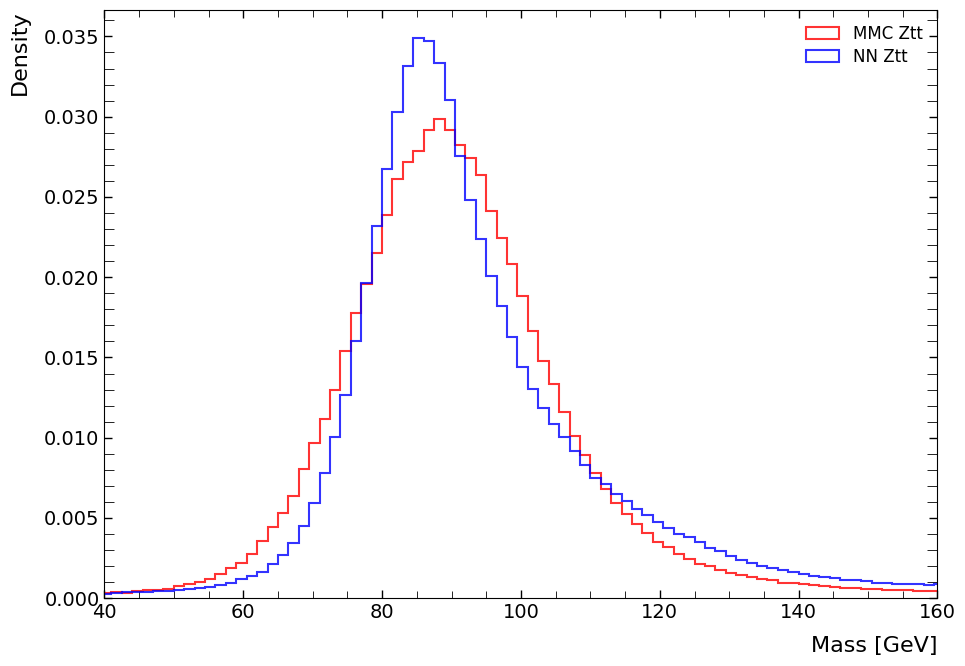

In [24]:
# MMC vs NN Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',
         label='MMC Ztt', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(40, 160)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
plt.savefig('out/Ztt_NN_MMC_phi.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

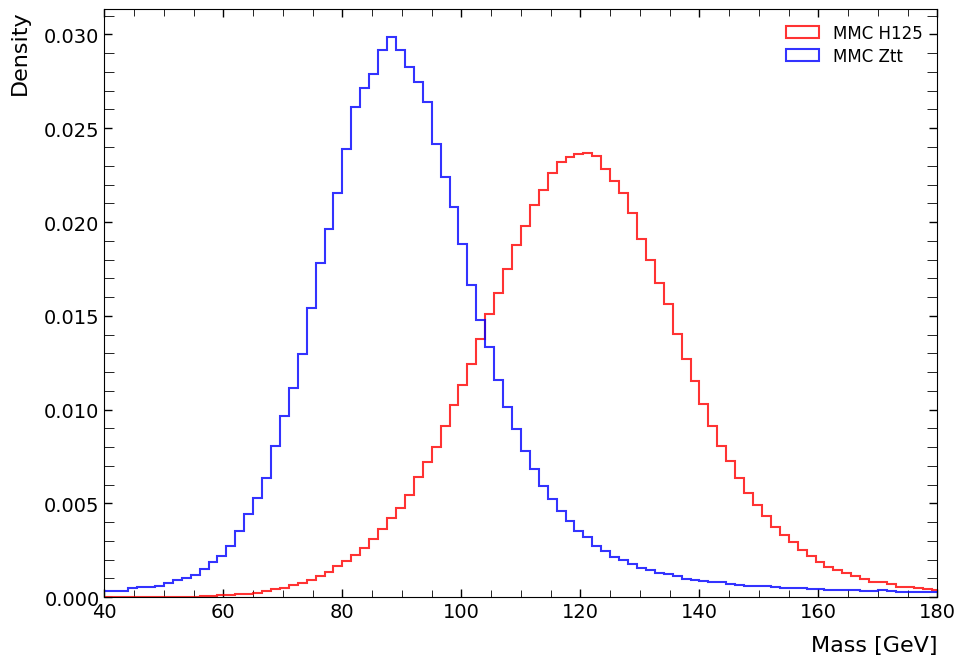

In [25]:
#MMC vs MMC H125 Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_mmc_H125, bins=120, range=(20, 200), histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',
         label='MMC Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(40, 180)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
plt.savefig('out/H125_Ztt_MMC_phi.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

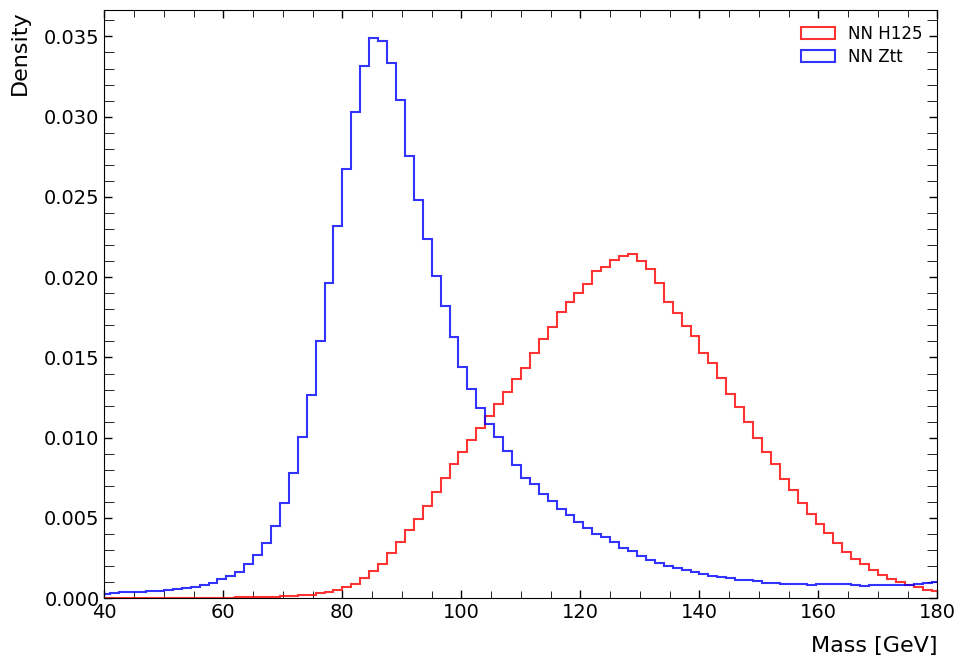

In [26]:
#NN vs NN H125 Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_pred_H125, bins=120, range=(20, 200), histtype='step',
         label='NN H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(40, 180)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
plt.savefig('out/H125_Ztt_NN_phi.png', dpi=300)
plt.tight_layout()
plt.show()  

In [ ]:
# MMC vs NN vs True H125
plt.figure(figsize=(10, 7))
plt.hist(y_true_H125, bins=120, range=(20, 200), histtype='step',
         label='True H125', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_H125, bins=120, range=(20, 200), histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=120, range=(20, 200), histtype='step',
         label='NN H125', density=True, color='Orange', alpha=0.8, linewidth=1.5)   

plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(70, 170)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.savefig('out/H125_True_NN_MMC_phi.png', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Your plotting code
plt.figure(figsize=(10, 6))
plt.hist(y_true_Ztt, bins=1000, histtype='step', label=f'True Ztt Mass Values (MMC)', density=True)
plt.hist(y_true_H125, bins=1000, histtype='step', label=f'True H125 Mass Values (MMC)', density=True)
plt.hist(y_pred_Ztt, bins=1000, histtype='step', label=f'Predcted Ztt Mass Values (MMC)', density=True)
plt.hist(y_pred_H125, bins=1000, histtype='step', label=f'Predcted H125 Mass Values (MMC)', density=True)
plt.xlabel("MMC Value")
plt.ylabel("Density")
plt.xlim(50, 180)
plt.title("Comparison of MMC Distributions on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig("mmc_distribution_comparison.png", dpi=300)

# --- Rest of your original code if needed for prediction comparison ---
# y_pred = model.model.predict(dataset_h125_obj.val_dataset.batch(10000)).squeeze()
# y_pred_Ztt = model.model.predict(dataset_Ztt_obj.val_dataset.batch(10000)).squeeze()